# Blackbox Optimisation Project: Phase 1.2

This code classifies the data with a binary "promising" channel.  <br><br> -- Data points with an output in the upper quartile of values are given a "promising" value of 1, others are 0 <br> -- A convex hull is then drawn around the subset of points defined as being "promising" <br> -- This convex hull is then searched for the most-isolated point as in phase 1.1, but the search region is now concentrated around points that appear to be close to the maximum

In [19]:
week = 4
function = 2

Import Standard Libraries

In [20]:
import pandas as pd
import numpy as np
import importlib

from pathlib import Path

import matplotlib.pyplot as plt

Import Project Packages

In [21]:
import bbo_project.data_loading as data_loading
import bbo_project.data_augmentation as data_augmentation
import bbo_project.data_plotting as data_plotting

importlib.reload(data_loading)
importlib.reload(data_augmentation)
importlib.reload(data_plotting)

<module 'bbo_project.data_plotting' from 'C:\\Users\\gajones\\Desktop\\bbo_project\\src\\bbo_project\\data_plotting.py'>

### Import and Update Data

In [ ]:
print(f"Requested function {function} in week {week}")

print("\nData Loading")

# return path for required dataset
PROJECT_DIR, data_folder_name, week_folder_name = data_loading.get_working_week(week, function)

# load initial data
df = data_loading.load_initial_data(PROJECT_DIR, data_folder_name)

# Add updated points
df = data_loading.apply_updates(df, week, data_folder_name)

# create file structure for saving results to
results_dir = data_loading.create_results_dir(week_folder_name, data_folder_name)
print(f"\tresults will be saved to {results_dir}...")

print("\nData Preprocessing")
input_cols = data_loading.get_X_cols(df)

print("\t scaling outputs")
df["YScaled"] = data_augmentation.minmax_scale(df["Y1"])

print("\tclassify promising regions")
quantile = 0.75
threshold = df["YScaled"].quantile(quantile)

while (df["YScaled"] >= threshold).astype(int).sum() < len(input_cols) + 1:
    quantile = quantile - 0.05
    threshold = df["YScaled"].quantile(quantile)

    print(quantile)

df["promising"] = (df["YScaled"] >= threshold).astype(int)

print("separating inputs and outputs")

df_inputs = df[input_cols]
df_output = df["YScaled"]

Requested function 2 in week 4

Data Loading
	Loaded initial data: function_2
	Available update files:
		1: new_data_point_wk1.csv
		2: new_data_point_wk10.csv
		3: new_data_point_wk2.csv
		4: new_data_point_wk3.csv
		5: new_data_point_wk4.csv
		6: new_data_point_wk5.csv
		7: new_data_point_wk6.csv
		8: new_data_point_wk7.csv
		9: new_data_point_wk8.csv
		10: new_data_point_wk9.csv
	Added 3 new data points.
	results will be saved to c:\Users\gajones\Desktop\bbo_project\results\plots\week_4\function_2...

Data Preprocessing
	 scaling outputs
	classify promising regions
separating inputs and outputs


In [23]:
print(f"\n Current Max Value: {df['Y1'].max()}")


 Current Max Value: 0.6112052157614438


### Augment data set

Find most isolated point in the input space, bound by the convex hull of all inputs data

In [24]:
df_hull = df[df["promising"] == 1]
df_hull_inputs = df_hull[input_cols]

print("Calculate Convex Hull around promising data points only")
hull, points_hull = data_augmentation.compute_convex_hull(df_hull_inputs)

print("Find most isolated point within convex hull")

best_point, best_dist = data_augmentation.most_isolated_point(points_hull, hull, n_samples=10000, seed=42)

def to_dict(point, columns):
    return {col: val for col, val in zip(columns, point)}

best_point_dict = to_dict(best_point, input_cols)

Calculate Convex Hull around promising data points only
Find most isolated point within convex hull
	generating random seeds...
	finding internal points...
	looking for furthest points...


### Plot Results

In [25]:
points = df_inputs.to_numpy()
new_point_flag = df["new data point"].to_numpy()

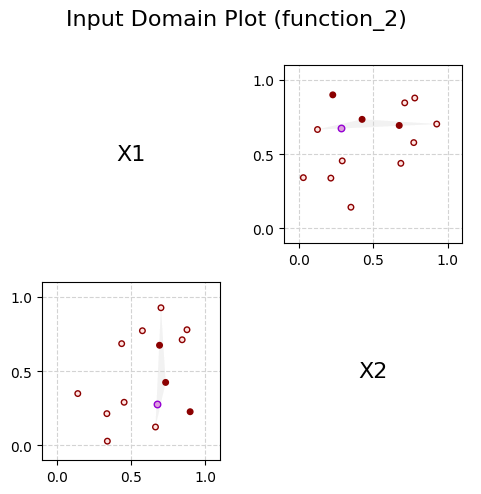

In [26]:
data_plotting.domain_plot(data_folder_name, results_dir, input_cols, points, points_hull, new_point_flag, hull = hull,next_point = best_point_dict)

write results to csv

write results to csv

In [8]:
data_loading.append_results(results_dir, data_folder_name, best_point_dict)

In [9]:
s = "-".join(f"{v:.6f}" for v in best_point_dict.values())
print(s)

0.665810-0.440376
